In [1]:
import sys
import subprocess
import pandas as pd
import numpy as np
import requests
from dotenv import load_dotenv
import os
from sqlalchemy import create_engine
import tweepy
import openai
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import xgboost as xgb
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import streamlit as st

# Step 0: Connecting to SQL Database

In [2]:
# Verify Database and proper tokens exist in .env file
from dotenv import load_dotenv

load_dotenv()

print("Database URL found:", os.getenv("DATABASE_URL") is not None)
print("Twitter token found:", os.getenv("X_BEARER_TOKEN") is not None)

Database URL found: True
Twitter token found: True


In [3]:
# Connect to the database and run a simple query to verify connection
from sqlalchemy import create_engine, text

engine = create_engine(os.getenv("DATABASE_URL"))

with engine.connect() as conn:
    result = conn.execute(
        text("SELECT current_database(), current_user")
    )
    
    print(result.fetchone())

('twitter_engagement', 'postgres')


In [4]:
# Verify tables exist in the database
query = """
SELECT table_name
FROM information_schema.tables
WHERE table_schema = 'public'
ORDER BY table_name
"""

with engine.connect() as conn:
    result = conn.execute(text(query))

    for row in result:
        print(row[0])

tweet_labels
tweet_media
tweets
users


# Step 1: Getting Twitter Data

In [5]:
import os
import re
import json
import pandas as pd
import tweepy

from dotenv import load_dotenv
from sqlalchemy import create_engine, text

load_dotenv()

engine = create_engine(os.getenv("DATABASE_URL"))

client = tweepy.Client(
    bearer_token=os.getenv("X_BEARER_TOKEN"),
    wait_on_rate_limit=True
)

print("Setup complete")

Setup complete


In [6]:
# Text cleaning function
def clean_tweet_text(text):
    if text is None:
        return None
    
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "@USER", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"\s+", " ", text)
    
    return text.strip()

In [10]:
# Defining time windows and test queries for data collection
from datetime import datetime, timedelta, timezone
import pandas as pd

now = datetime.now(timezone.utc)

# Each tuple is: (start_days_ago, end_days_ago)
# Example: 7.0 to 6.8 days ago means older tweets with time to gain engagement.
time_windows = [
    (7.0, 6.8),
    (6.8, 6.6),
    (6.6, 6.4),
    (6.4, 6.2),
    (6.2, 6.0)
]

test_queries = {
    "broad_general": '("the" OR "this" OR "you" OR "that" OR "with") lang:en -is:retweet',
    "questions": '("why" OR "how" OR "what" OR "when" OR "where") lang:en -is:retweet',
    "opinions": '("best" OR "worst" OR "favorite" OR "overrated" OR "underrated") lang:en -is:retweet',
    "entertainment": '("movie" OR "music" OR "game" OR "show" OR "book") lang:en -is:retweet',
    "life_topics": '("food" OR "travel" OR "work" OR "school" OR "fitness") lang:en -is:retweet'
}


In [11]:
# Test collection
all_responses = []

for query_name, query_text in test_queries.items():
    for start_days, end_days in time_windows:
        start_time = now - timedelta(days=start_days)
        end_time = now - timedelta(days=end_days)

        start_time_str = start_time.isoformat(timespec="seconds").replace("+00:00", "Z")
        end_time_str = end_time.isoformat(timespec="seconds").replace("+00:00", "Z")

        response = client.search_recent_tweets(
            query=query_text,
            max_results=10,
            start_time=start_time_str,
            end_time=end_time_str,
            sort_order="relevancy",
            tweet_fields=[
                "created_at",
                "author_id",
                "lang",
                "public_metrics",
                "entities",
                "attachments",
                "referenced_tweets"
            ],
            expansions=[
                "attachments.media_keys",
                "author_id",
                "referenced_tweets.id"
            ],
            media_fields=[
                "media_key",
                "type",
                "url",
                "preview_image_url",
                "alt_text",
                "width",
                "height",
                "duration_ms",
                "public_metrics"
            ],
            user_fields=[
                "username",
                "name",
                "verified",
                "public_metrics"
            ]
        )

        tweet_count = 0 if response.data is None else len(response.data)

        print(
            f"{query_name} | {start_time_str} to {end_time_str} | tweets returned: {tweet_count}"
        )

        all_responses.append({
            "query_name": query_name,
            "query_text": query_text,
            "start_time": start_time_str,
            "end_time": end_time_str,
            "response": response,
            "tweet_count": tweet_count
        })

print("Total API calls made:", len(all_responses))
print("Total tweets returned before deduping:", sum(r["tweet_count"] for r in all_responses))

broad_general | 2026-06-03T19:59:05Z to 2026-06-04T00:47:05Z | tweets returned: 10
broad_general | 2026-06-04T00:47:05Z to 2026-06-04T05:35:05Z | tweets returned: 10
broad_general | 2026-06-04T05:35:05Z to 2026-06-04T10:23:05Z | tweets returned: 10
broad_general | 2026-06-04T10:23:05Z to 2026-06-04T15:11:05Z | tweets returned: 8
broad_general | 2026-06-04T15:11:05Z to 2026-06-04T19:59:05Z | tweets returned: 10
questions | 2026-06-03T19:59:05Z to 2026-06-04T00:47:05Z | tweets returned: 9
questions | 2026-06-04T00:47:05Z to 2026-06-04T05:35:05Z | tweets returned: 10
questions | 2026-06-04T05:35:05Z to 2026-06-04T10:23:05Z | tweets returned: 10
questions | 2026-06-04T10:23:05Z to 2026-06-04T15:11:05Z | tweets returned: 9
questions | 2026-06-04T15:11:05Z to 2026-06-04T19:59:05Z | tweets returned: 9
opinions | 2026-06-03T19:59:05Z to 2026-06-04T00:47:05Z | tweets returned: 8
opinions | 2026-06-04T00:47:05Z to 2026-06-04T05:35:05Z | tweets returned: 9
opinions | 2026-06-04T05:35:05Z to 2026-

In [12]:
# Vareity check

test_rows = []

for item in all_responses:
    response = item["response"]

    for tweet in response.data or []:
        metrics = tweet.public_metrics or {}

        test_rows.append({
            "tweet_id": str(tweet.id),
            "query_name": item["query_name"],
            "start_time_window": item["start_time"],
            "end_time_window": item["end_time"],
            "created_at": tweet.created_at,
            "text": tweet.text,
            "like_count": metrics.get("like_count", 0),
            "reply_count": metrics.get("reply_count", 0),
            "retweet_count": metrics.get("retweet_count", 0),
            "quote_count": metrics.get("quote_count", 0),
        })

test_df = pd.DataFrame(test_rows)

test_df["engagement_total"] = (
    test_df["like_count"] +
    test_df["reply_count"] +
    test_df["retweet_count"] +
    test_df["quote_count"]
)

test_df = test_df.drop_duplicates(subset="tweet_id")

print("Unique tweets:", len(test_df))
print("Unique queries represented:", test_df["query_name"].nunique())
print("Created_at range:", test_df["created_at"].min(), "to", test_df["created_at"].max())

display(
    test_df[[
        "query_name",
        "created_at",
        "like_count",
        "reply_count",
        "retweet_count",
        "quote_count",
        "engagement_total",
        "text"
    ]]
    .sort_values("engagement_total", ascending=False)
    .head(25)
)

Unique tweets: 238
Unique queries represented: 5
Created_at range: 2026-06-03 20:00:21+00:00 to 2026-06-04 19:53:28+00:00


,query_name,created_at,like_count,reply_count,retweet_count,quote_count,engagement_total,text
233,life_topics,2026-06-04 19:17:15+00:00,599,221,47,248,1115,What fast food spot did you work at? I worked ...
213,life_topics,2026-06-04 08:58:13+00:00,236,57,182,0,475,I went to work as normal one night and what i ...
65,questions,2026-06-04 04:15:48+00:00,164,6,5,2,177,Now that my body and mind are finally in a pla...
47,broad_general,2026-06-04 15:29:06+00:00,87,44,33,1,165,"The more time you spend with AI, the more huma..."
157,entertainment,2026-06-04 02:47:52+00:00,105,0,33,2,140,"[MUSIC SHOW]\n\n📅 June 6th, (Sat)\nDon’t miss ..."
66,questions,2026-06-04 04:16:58+00:00,100,4,5,0,109,@brianros1 How could you say there is 0 fraud?...
187,entertainment,2026-06-04 18:15:39+00:00,87,20,0,2,109,give me book/show/movie recs that are similar ...
75,questions,2026-06-04 09:12:38+00:00,85,1,2,0,88,Q: How much does community feedback matter?\n\...
5,broad_general,2026-06-03 20:40:27+00:00,58,15,3,1,77,Knicks vs Spurs - Game 1:\n\nI love capping Re...
93,questions,2026-06-04 17:45:10+00:00,44,4,20,0,68,“We must recapture our heritage and our identi...


In [25]:
# DataFrame creation from multiple query/time-window responses

tweet_rows = []
media_rows = []
user_rows = []

for item in all_responses:
    response = item["response"]
    query_name = item["query_name"]
    query_text = item["query_text"]
    start_time_window = item["start_time"]
    end_time_window = item["end_time"]

    tweets = response.data or []
    includes = response.includes or {}

    media_lookup = {
        media.data["media_key"]: media
        for media in includes.get("media", [])
    }

    # users
    for user in includes.get("users", []):
        metrics = user.data.get("public_metrics", {})

        user_rows.append({
            "author_id": str(user.id),
            "username": user.data.get("username"),
            "name": user.data.get("name"),
            "verified": user.data.get("verified"),
            "followers_count": metrics.get("followers_count", 0),
            "following_count": metrics.get("following_count", 0),
            "tweet_count": metrics.get("tweet_count", 0),
            "listed_count": metrics.get("listed_count", 0),
            "raw_json": json.dumps(user.data)
        })

    # tweets and media
    for tweet in tweets:
        metrics = tweet.public_metrics or {}
        attachments = tweet.data.get("attachments", {})
        media_keys = attachments.get("media_keys", [])

        tweet_rows.append({
            "tweet_id": str(tweet.id),
            "author_id": str(tweet.author_id),
            "created_at": tweet.created_at,
            "text": tweet.text,
            "clean_text": clean_tweet_text(tweet.text),
            "lang": tweet.lang,

            "retweet_count": metrics.get("retweet_count", 0),
            "reply_count": metrics.get("reply_count", 0),
            "like_count": metrics.get("like_count", 0),
            "quote_count": metrics.get("quote_count", 0),

            "has_media": len(media_keys) > 0,
            "media_count": len(media_keys),

            "collection_source": query_name,
            "search_query": query_text,

            # useful for testing; not currently in your database unless you add columns
            "start_time_window": start_time_window,
            "end_time_window": end_time_window,

            "raw_json": json.dumps(tweet.data)
        })

        for media_key in media_keys:
            media = media_lookup.get(media_key)

            if media is None:
                continue

            media_rows.append({
                "media_key": media_key,
                "tweet_id": str(tweet.id),
                "media_type": media.data.get("type"),
                "url": media.data.get("url"),
                "preview_image_url": media.data.get("preview_image_url"),
                "alt_text": media.data.get("alt_text"),
                "width": media.data.get("width"),
                "height": media.data.get("height"),
                "duration_ms": media.data.get("duration_ms"),
                "public_metrics": json.dumps(media.data.get("public_metrics", {})),
                "raw_json": json.dumps(media.data)
            })

tweets_df = pd.DataFrame(tweet_rows)
media_df = pd.DataFrame(media_rows)
users_df = pd.DataFrame(user_rows)

# Deduplicate
if len(tweets_df) > 0:
    tweets_df = tweets_df.drop_duplicates(subset="tweet_id").copy()

if len(media_df) > 0:
    media_df = media_df.drop_duplicates(subset="media_key").copy()

if len(users_df) > 0:
    users_df = users_df.drop_duplicates(subset="author_id").copy()

# Engagement features
if len(tweets_df) > 0:
    tweets_df["engagement_total"] = (
        tweets_df["like_count"] +
        tweets_df["reply_count"] +
        tweets_df["retweet_count"] +
        tweets_df["quote_count"]
    )

    tweets_df = tweets_df.sort_values(by="engagement_total", ascending=False)



tweets_df["eligible_for_labeling"] = (
    tweets_df["engagement_total"] >= 2
)

# Propagate eligible_for_labeling to media_df and users_df
tweet_eligibility_lookup = (
    tweets_df
    .set_index("tweet_id")["eligible_for_labeling"]
    .to_dict()
)

user_eligibility_lookup = (
    tweets_df
    .groupby("author_id")["eligible_for_labeling"]
    .any()
    .to_dict()
)

if len(media_df) > 0:
    media_df["eligible_for_labeling"] = (
        media_df["tweet_id"]
        .map(tweet_eligibility_lookup)
        .fillna(False)
    )
else:
    media_df["eligible_for_labeling"] = pd.Series(dtype=bool)

if len(users_df) > 0:
    users_df["eligible_for_labeling"] = (
        users_df["author_id"]
        .map(user_eligibility_lookup)
        .fillna(False)
    )
else:
    users_df["eligible_for_labeling"] = pd.Series(dtype=bool)

display(tweets_df.head())
display(media_df.head())
display(users_df.head())

,tweet_id,author_id,created_at,text,clean_text,lang,retweet_count,reply_count,like_count,quote_count,has_media,media_count,collection_source,search_query,start_time_window,end_time_window,raw_json,engagement_total,eligible_for_labeling
233,2062614676660187382,94844786,2026-06-04 19:17:15+00:00,What fast food spot did you work at? I worked ...,What fast food spot did you work at? I worked ...,en,47,221,599,248,False,0,life_topics,"(""food"" OR ""travel"" OR ""work"" OR ""school"" OR ""...",2026-06-04T15:11:05Z,2026-06-04T19:59:05Z,"{""public_metrics"": {""retweet_count"": 47, ""repl...",1115,True
213,2062458895390429651,1327639130017312768,2026-06-04 08:58:13+00:00,I went to work as normal one night and what i ...,I went to work as normal one night and what i ...,en,182,57,236,0,False,0,life_topics,"(""food"" OR ""travel"" OR ""work"" OR ""school"" OR ""...",2026-06-04T05:35:05Z,2026-06-04T10:23:05Z,"{""id"": ""2062458895390429651"", ""edit_history_tw...",475,True
65,2062387822456442881,1344797877592182786,2026-06-04 04:15:48+00:00,Now that my body and mind are finally in a pla...,Now that my body and mind are finally in a pla...,en,5,6,164,2,False,0,questions,"(""why"" OR ""how"" OR ""what"" OR ""when"" OR ""where""...",2026-06-04T00:47:05Z,2026-06-04T05:35:05Z,"{""text"": ""Now that my body and mind are finall...",177,True
47,2062557262192030202,1690352207252819968,2026-06-04 15:29:06+00:00,"The more time you spend with AI, the more huma...","The more time you spend with AI, the more huma...",en,33,44,87,1,True,1,broad_general,"(""the"" OR ""this"" OR ""you"" OR ""that"" OR ""with"")...",2026-06-04T15:11:05Z,2026-06-04T19:59:05Z,"{""author_id"": ""1690352207252819968"", ""lang"": ""...",165,True
157,2062365693845381311,1886974129452277763,2026-06-04 02:47:52+00:00,"[MUSIC SHOW]\n\n📅 June 6th, (Sat)\nDon’t miss ...","[MUSIC SHOW] 📅 June 6th, (Sat) Don’t miss the ...",en,33,0,105,2,True,3,entertainment,"(""movie"" OR ""music"" OR ""game"" OR ""show"" OR ""bo...",2026-06-04T00:47:05Z,2026-06-04T05:35:05Z,"{""attachments"": {""media_keys"": [""3_20623656186...",140,True


,media_key,tweet_id,media_type,url,preview_image_url,alt_text,width,height,duration_ms,public_metrics,raw_json,eligible_for_labeling
0,3_2062308626014896128,2062308664665370757,photo,https://pbs.twimg.com/media/HJ7KxM7XgAAUfLa.jpg,NaN,NaN,3060,4080,NaN,{},"{""media_key"": ""3_2062308626014896128"", ""width""...",False
1,3_2062308644943732736,2062308664665370757,photo,https://pbs.twimg.com/media/HJ7KyTcWoAAVkNE.jpg,NaN,NaN,3060,4080,NaN,{},"{""media_key"": ""3_2062308644943732736"", ""width""...",False
2,3_2062272449358569472,2062273226848301454,photo,https://pbs.twimg.com/media/HJ6p3cYXoAA17Qv.jpg,NaN,NaN,768,363,NaN,{},"{""media_key"": ""3_2062272449358569472"", ""width""...",True
3,3_2062287541886201856,2062287543513620693,photo,https://pbs.twimg.com/media/HJ63l8bXMAAjHIV.png,NaN,NaN,534,534,NaN,{},"{""media_key"": ""3_2062287541886201856"", ""width""...",True
4,16_2062264709294821377,2062264860012888125,animated_gif,NaN,https://pbs.twimg.com/tweet_video_thumb/HJ6i06...,NaN,400,300,NaN,{},"{""media_key"": ""16_2062264709294821377"", ""width...",False


,author_id,username,name,verified,followers_count,following_count,tweet_count,listed_count,raw_json,eligible_for_labeling
0,1393709868016705537,davidsibande125,DAVID🇿🇦 SIBANDE,False,1392,5234,1414,1,"{""name"": ""DAVID\ud83c\uddff\ud83c\udde6 SIBAND...",False
1,2318005855,MrSilhouette,MrSilhouette,False,471,411,13716,3,"{""name"": ""MrSilhouette"", ""id"": ""2318005855"", ""...",False
2,2004998029053505536,FactsMatter_2me,Facts Matter,False,62,64,304,0,"{""name"": ""Facts Matter"", ""id"": ""20049980290535...",False
3,1820646855296045056,TheDruidic1,Andruid,False,993,2913,10690,5,"{""name"": ""Andruid"", ""id"": ""1820646855296045056...",False
4,1360404593381961730,TheLiberalScam,TheLiberalScam,False,129,149,5079,1,"{""name"": ""TheLiberalScam"", ""id"": ""136040459338...",True


engagement_total    14.558824
dtype: float64
238
count     238.000000
mean       14.558824
std        81.163446
min         0.000000
25%         0.000000
50%         1.000000
75%         3.000000
max      1115.000000
Name: engagement_total, dtype: float64


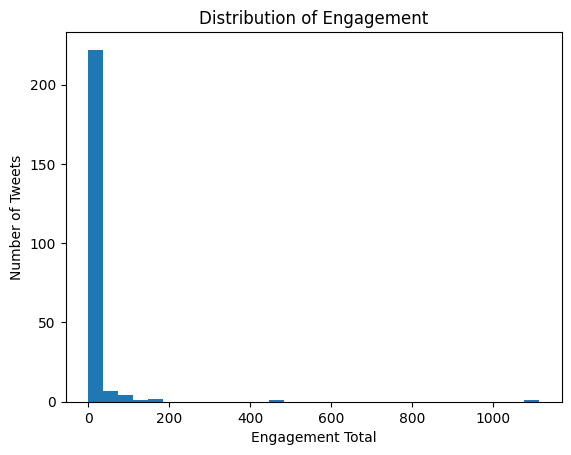

In [26]:

print(tweets_df[['engagement_total']].mean())
print(len(tweets_df))
print(tweets_df["engagement_total"].describe())

import matplotlib.pyplot as plt

plt.hist(tweets_df["engagement_total"], bins=30)
plt.xlabel("Engagement Total")
plt.ylabel("Number of Tweets")
plt.title("Distribution of Engagement")
plt.show()

In [27]:
print("Tweets:", len(tweets_df))
print("Media:", len(media_df))
print("Users:", len(users_df))

print("Duplicate tweets:", tweets_df["tweet_id"].duplicated().sum())
print("Duplicate media:", media_df["media_key"].duplicated().sum() if len(media_df) > 0 else 0)
print("Duplicate users:", users_df["author_id"].duplicated().sum() if len(users_df) > 0 else 0)

print(tweets_df["engagement_total"].describe())

Tweets: 238
Media: 78
Users: 228
Duplicate tweets: 0
Duplicate media: 0
Duplicate users: 0
count     238.000000
mean       14.558824
std        81.163446
min         0.000000
25%         0.000000
50%         1.000000
75%         3.000000
max      1115.000000
Name: engagement_total, dtype: float64
